In [123]:
with open('names.txt', 'r') as f:
    names = f.readlines()

chars =  ['.'] + sorted(set( ch for name in names for ch in name.strip())) 

print(type(chars))
print(chars)
stoi = { ch:i for i, ch in enumerate(chars)}
itos = { i:ch for i, ch in enumerate(chars)}

print(stoi)
print(itos)



<class 'list'>
['.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
{'.': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26}
{0: '.', 1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z'}


In [124]:
embedding_size = 24
context_length = 8
hidden_size = 128
mini_batch = 32
epochs = 200000
weight_decay = 0.1
vocab_size = len(chars)

In [125]:
import torch
torch.manual_seed(42)

In [126]:
X_train  = []
Y_train = []
X_val = []
Y_val = []
import random
random.seed(42)
random.shuffle(names)
total_len = len(names)
train_len = int(total_len * 0.9)
val_len = total_len - train_len
train_names = names[:train_len]
val_names = names[train_len:]
for name in train_names:
    name =  name.strip()
    context = [0] * context_length
    for ch in name + '.':
        input = [itos[c] for c in context]
        
        X_train.append(context)
        Y_train.append(stoi[ch])
        context = context[1:] + [stoi[ch]]
for name in val_names:
    name =  name.strip()
    context = [0] * context_length
    for ch in name + '.':
        input = [itos[c] for c in context]
        
        X_val.append(context)
        Y_val.append(stoi[ch])
        context = context[1:] + [stoi[ch]]

import torch
g = torch.Generator().manual_seed(2147483647) # for reproducibility
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)
X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)


In [127]:


from re import M


class Linear:
    def __init__(self, n_in, n_out, bias=True):
        self.w = torch.randn((n_in, n_out), generator=g) * (5/3) * (1/ (n_in)**0.5)
        self.b = torch.randn((n_out), generator=g) if bias else None
        self.bias = bias 
    
    def __call__(self, x):
        self.out = x @ self.w
        if self.bias:
            self.out += self.b
        return self.out
    
    def parameters(self):
        if self.bias:
            return [self.w, self.b]
        else:
            return [self.w]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
    

class BatchNorm1d:
    def __init__(self, dim, eps=1e-05, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.scale = torch.ones(dim)
        self.shift = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        if self.training:
            if x.ndim == 2:
                dim = (0)
            elif x.ndim == 3:
                dim = (0,1)
            xmean = x.mean(dim=dim, keepdim=True)
            xvar = x.var(dim=dim, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        I_std = xvar.sqrt() + self.eps
        I_mean = xmean
        x = (x - I_mean) / I_std
        self.out = self.scale * x + self.shift
        if self.training:
            with torch.no_grad():
                self.running_mean = self.momentum * self.running_mean + (1 - self.momentum) * I_mean
                self.running_var = self.momentum * self.running_var + (1 - self.momentum) * I_std
        return self.out
    
    def parameters(self):
        return [self.scale, self.shift]
    
class CrossEntropyLoss:
    def __call__(self, x, y):
        return torch.nn.functional.cross_entropy(x, y)
    

class Embedding:
    def __init__(self, vocab_size, embedding_size):
        self.C = torch.randn((vocab_size, embedding_size))
        
    def __call__(self, x):
        self.out = self.C[x]
        return self.out
    
    def parameters(self):
        return [self.C]

class FlattenConsecutive:
    def __init__(self, n):
        self.n = n 

    def __call__(self, x):
        (a, b, c) = x.shape
        x = x.view(a, b//self.n, c * self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []
    

class Sequential:
    def __init__(self, layers):
        self.layers = layers
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    

In [128]:

model =Sequential( [
    Embedding(vocab_size, embedding_size), 
    FlattenConsecutive(2), Linear(2 * embedding_size, hidden_size),  BatchNorm1d(hidden_size), Tanh(), 
    FlattenConsecutive(2), Linear(hidden_size * 2, hidden_size, bias = False), BatchNorm1d(hidden_size), Tanh(), 
    
    FlattenConsecutive(2), Linear(hidden_size * 2, vocab_size, bias = False), BatchNorm1d(vocab_size),

])


for p in model.parameters():
  p.requires_grad = True


In [129]:
losses = []
ud = []
um = []
for i in range(epochs):
    samples = torch.randint(0, X_train.shape[0], (mini_batch,))
    mini_batch_X = X_train[samples]
    mini_batch_Y = Y_train[samples]
    
    O = model(mini_batch_X)
    loss = CrossEntropyLoss()(O, mini_batch_Y)
    for layer in model.layers:
        layer.out.retain_grad()
    for p in model.parameters():    
        p.grad = None
    
    loss.backward()
    losses.append(loss.item())
    print("training loss: ", loss.item())
    lr = 0.01 if i < 10000 else 0.001
    for p in model.parameters():
        p.data -= p.grad * lr
        
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in model.parameters()])
    with torch.no_grad():
        um.append([((lr*p.grad).mean() / p.data.mean()).log10().item() for p in model.parameters()])
        
    

training loss:  3.3937270641326904
training loss:  3.7818968296051025
training loss:  3.909700632095337
training loss:  3.8909449577331543
training loss:  3.751814842224121
training loss:  3.6437129974365234
training loss:  3.623032808303833
training loss:  3.355008602142334
training loss:  3.670825481414795
training loss:  3.2308270931243896
training loss:  3.5491514205932617
training loss:  3.7528159618377686
training loss:  3.561532974243164
training loss:  3.595954179763794
training loss:  3.5921099185943604
training loss:  3.516540288925171
training loss:  3.4234166145324707
training loss:  3.513014078140259
training loss:  3.5947580337524414
training loss:  3.367051839828491
training loss:  3.4476568698883057
training loss:  3.4316046237945557
training loss:  3.4066054821014404
training loss:  3.4842638969421387
training loss:  3.683528423309326
training loss:  3.5002644062042236
training loss:  3.2733283042907715
training loss:  3.4343812465667725
training loss:  3.5545885562896

200000
torch.Size([1000])


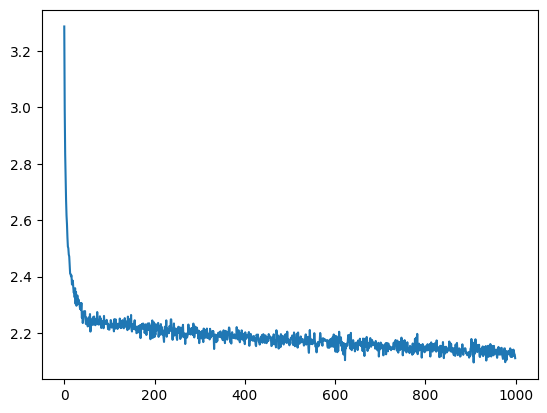

In [130]:
import matplotlib.pyplot as plt
print(len(losses))
losses = torch.tensor(losses)
losses = losses.view(-1, 200)
losses = losses.mean(1)
print(losses.shape)
plt.plot(losses)


In [131]:
import torch
e =  torch.randn((4, 8, 10))
print(e.shape)
even = e[:, 0::2]
print(even.shape)
odd = e[:, 1::2]
print(odd.shape)
overall = torch.cat((e[:, ::2], e[:, 1::2]), dim=-1)
print(overall.shape)
print((e.view(4, 4, 20) == overall).all())



torch.Size([4, 8, 10])
torch.Size([4, 4, 10])
torch.Size([4, 4, 10])
torch.Size([4, 4, 20])
tensor(True)


In [132]:
for layer in model.layers:
    print(layer.__class__.__name__)
    print(layer.out.shape)

Embedding
torch.Size([32, 8, 24])
FlattenConsecutive
torch.Size([32, 4, 48])
Linear
torch.Size([32, 4, 128])
BatchNorm1d
torch.Size([32, 4, 128])
Tanh
torch.Size([32, 4, 128])
FlattenConsecutive
torch.Size([32, 2, 256])
Linear
torch.Size([32, 2, 128])
BatchNorm1d
torch.Size([32, 2, 128])
Tanh
torch.Size([32, 2, 128])
FlattenConsecutive
torch.Size([32, 256])
Linear
torch.Size([32, 27])
BatchNorm1d
torch.Size([32, 27])


In [133]:
torch.no_grad()
o = model(X_val)
loss = CrossEntropyLoss()(O, mini_batch_Y)
print(loss)

tensor(1.8174, grad_fn=<NllLossBackward0>)
